In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [4]:
df = pd.read_csv('linear_regression_dataset.csv')
df.head()

,Weight,Height
0,68.727006,134.798738
1,97.535715,147.272821
2,86.599697,143.758652
3,79.932924,130.028617
4,57.800932,127.802107


Text(0, 0.5, 'Height')

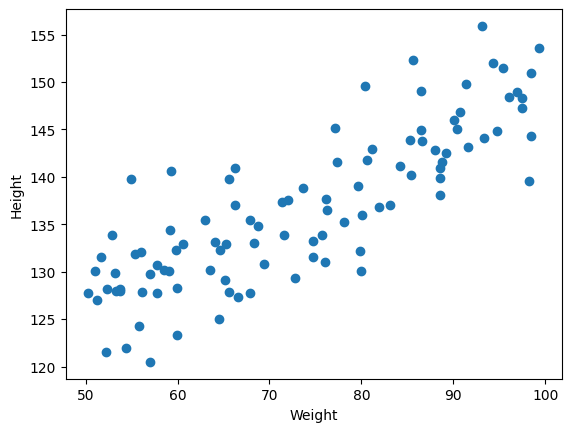

In [5]:
## scatter plot
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [6]:
## Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.831431
Height,0.831431,1.000000


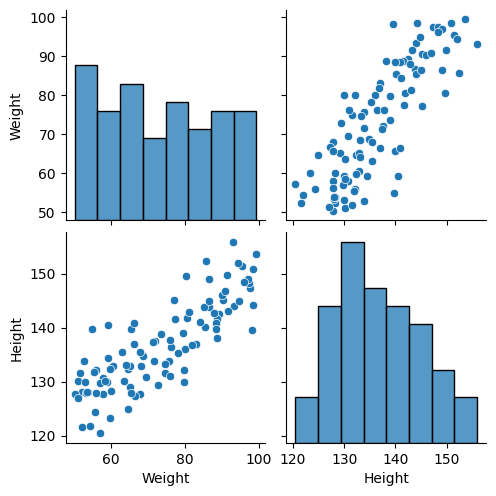

In [7]:
## Seaborn
import seaborn as sns
sns.pairplot(df)

### Input feature should be dataframe or 2 dim array
### Output feature can be 1 dim array

In [8]:
# Independent and Dependent feature
X = df[['Weight']]  ## independent features shld be dataframe or 2 dimensional array

X.head()

,Weight
0,68.727006
1,97.535715
2,86.599697
3,79.932924
4,57.800932


In [9]:
np.array(X).shape  # this is 2 dim as we need

(100, 1)

In [10]:
X_series = df['Weight']
np.array(X_series).shape   # this is one dimensional

(100,)

In [11]:
y = df['Height']  # this dependent feature can be in series or 1 dim array

np.array(y).shape

(100,)

In [12]:
# Train-Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.25, random_state=42)

In [13]:
X_train.shape

(25, 1)

In [14]:
## Standardization : take each ind feature and apply z score:  mean=0 and sd=1  (Zscore= (Xi-mean)/sd)
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  ## used for training data

In [16]:
X_test = scaler.transform(X_test) ## this is used so no data leakeage and train does not know about test data 

In [17]:
## Apply Simple LR
from sklearn.linear_model import LinearRegression

In [18]:
regression = LinearRegression(n_jobs=-1) # njobs run on how many processors are there

In [19]:
regression.fit(X_train, y_train)   

LinearRegression(n_jobs=-1)

In [20]:
regression.coef_   ## beeta_1

array([6.69344951])

In [21]:
regression.intercept_   ## beeta0

137.279478432

In [22]:
print(f"Coefficient or slope : {regression.coef_}")
print(f"Intercept : {regression.intercept_}")

Coefficient or slope : [6.69344951]
Intercept : 137.279478432


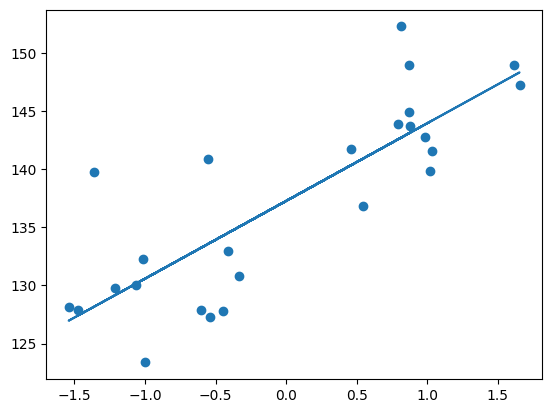

In [23]:
## plot best fit line
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train))

In [24]:
## Prediction for test data : y_pred = 37.279478432 +  (X_test) 
y_pred = regression.predict(X_test)

In [25]:
## Perfomance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [26]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

19.646533856002396
3.512967031722695
4.432441071915384


In [27]:
# R-Squared
from sklearn.metrics import r2_score

In [ ]:
score = r2_score(y_test, y_pred)
print(score)

0.6959017446443423


In [29]:
# Adjusted R-Squared
1 - (1 - score)*(len(y_test) - 1)/(len(y_test) - X_test.shape[1]-1)

0.6917360151189222

## OLS LR : 

In [30]:
import statsmodels.api as sm

In [31]:
model = sm.OLS(y_train, X_train).fit()

In [32]:
prediction = model.predict(X_test)
prediction

array([ -9.91027403,   9.75585106,   6.8557978 ,   4.25998813,
        -5.29172934,  -1.0008265 ,  -4.50238953,   9.00532786,
       -10.9269476 ,  -2.55308116,  -1.19499859,   2.95933447,
         7.8782156 ,  11.03475724,  -8.58457929,  -7.72285259,
         6.83274495,  -9.66218957,   8.27995637,  -7.37968251,
        10.39572506,   9.57570501,  -6.69006118, -10.60037254,
        11.93379266,  -7.0749589 ,  -8.52675951,   0.95285541,
         5.33761495, -11.28329265,  11.53214955,   0.8898115 ,
        -3.72076206,   2.60138291,   1.86473636,  -7.72342322,
        -8.0799556 ,   1.42514518,   7.71109391,  -4.21618518,
        -7.04065615,  11.4309451 ,   9.07802214,   0.26825964,
         0.75180085,  -4.52404859,   3.33202475,   7.16172337,
         8.19230053,  -6.3904254 ,  -0.62425122,   2.74910118,
         1.0007297 ,   4.7736199 ,   2.8072176 ,  -2.93336837,
       -10.03979513,  -4.7675985 ,  -4.20739563,  -0.24229492,
        -9.32038297,  -8.86144406,   2.73115649,  10.09

In [33]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.002
Model:                            OLS   Adj. R-squared (uncentered):             -0.039
Method:                 Least Squares   F-statistic:                            0.05699
Date:                Thu, 03 Apr 2025   Prob (F-statistic):                       0.813
Time:                        01:00:23   Log-Likelihood:                         -158.54
No. Observations:                  25   AIC:                                      319.1
Df Residuals:                      24   BIC:                                      320.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [34]:
## Prediciton for new data
regression.predict(scaler.transform([[75]]))

c:\Users\ayush\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([137.69452157])